# 01. PyTorch Workflow Fundamentals

The essence of machine learning and deep learning is to take some data from the past, build an algorithm (like a neural network) to discover patterns in it and use the discovered patterns to predict the future.

There are many ways to do this and many new ways are being discovered all the time.

But let's start small.

How about we start with a straight line?

And we see if we can build a PyTorch model that learns the pattern of the straight line and matches it.
## What we're going to cover

In this module we're going to cover a standard PyTorch workflow (it can be chopped and changed as necessary but it covers the main outline of steps).

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01_a_pytorch_workflow.png" width=900 alt="a pytorch workflow flowchat"/>

For now, we'll use this workflow to predict a simple straight line but the workflow steps can be repeated and changed depending on the problem you're working on.

Specifically, we're going to cover:

| **Topic** | **Contents** |
| ----- | ----- |
| **1. Getting data ready** | Data can be almost anything but to get started we're going to create a simple straight line |
| **2. Building a model** | Here we'll create a model to learn patterns in the data, we'll also choose a **loss function**, **optimizer** and build a **training loop**. |
| **3. Fitting the model to data (training)** | We've got data and a model, now let's let the model (try to) find patterns in the (**training**) data. |
| **4. Making predictions and evaluating a model (inference)** | Our model's found patterns in the data, let's compare its findings to the actual (**testing**) data. |
| **5. Saving and loading a model** | You may want to use your model elsewhere, or come back to it later, here we'll cover that. |
| **6. Putting it all together** | Let's take all of the above and combine it. |

In [ ]:
what_were_covering = {1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [ ]:
import torch
from torch import nn ## nn contains all of PyTorch's building blocks for neural network
import matplotlib.pyplot as plt

#check pytorch version
torch.__version__

'2.9.0+cu126'

## Data(Preparing and loading)
## 1. Data (preparing and loading)

I want to stress that "data" in machine learning can be almost anything you can imagine.
* A table of numbers (like a big Excel spreadsheet)
* images of any kind
*  videos (YouTube has lots of data!)
* audio files like songs or podcasts,
* protein structures(DNA)
* text and more.

![machine learning is a game of two parts:
1. Get data into a numerical representation
2. build or pick a model to learn patterns in that numerical representation
(https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-machine-learning-a-game-of-two-parts.png)

To showcase this, let's screate some *known* data using the linear regression formula

Well use a linear regression formula to make a straight line with known **parameters**

In [ ]:
#Create *Known* parameters
weight = 0.79#(b)
bias = 0.3 #(c)

#Create
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3158],
         [0.3316],
         [0.3474],
         [0.3632],
         [0.3790],
         [0.3948],
         [0.4106],
         [0.4264],
         [0.4422]]))

In [ ]:
len(X), len(y)

(50, 50)

## Splitting data into training and test sets (one of the most important ML in general)

Let's creaye a training and test set with data

In [ ]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train  = X[:train_split],y[:train_split]
X_test , y_test =X[train_split:], y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?
This is where the data explorers motto come in!
'Visualize,Visualize,Visualize!'

In [ ]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  """
  Plots training data, test data and compares predictions
  """

  plt.figure(figsize=(10,7))

  #plot training data in bliue
  plt.scatter(train_data,train_labels,c='b',s=8,label='Training data')

  #plot test data in green
  plt.scatter(test_data,test_labels,c='g',s=8,label='Testing data')

  if predictions is not None:
    #plot the predictions if they exist
    plt.scatter(test_data,predictions,c='r',s=4,label='Predictions')
  #show the legend
  plt.legend(prop={'size':14})

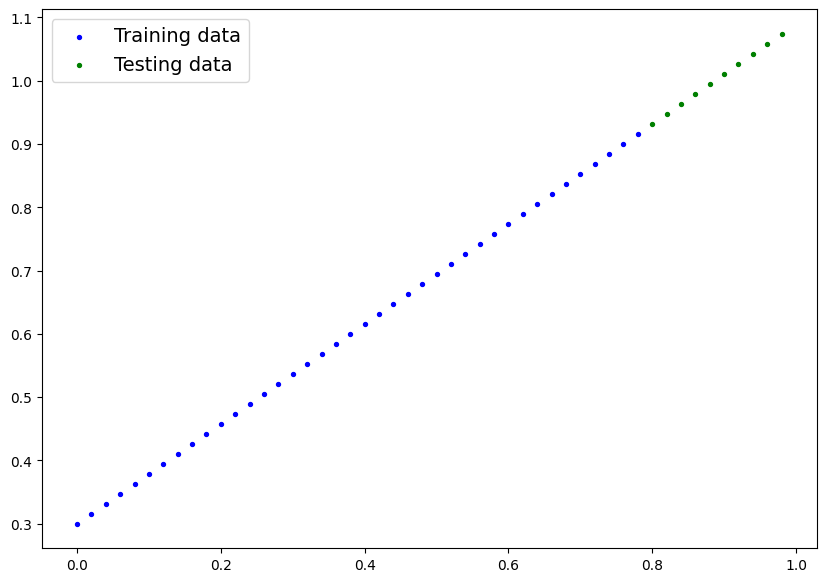

In [ ]:
plot_predictions();

## 2.Build our model

Our first Pytorch model!!
OOP:https://realpython.com/python3-object-oriented-programming/

What our model does:
* starts with random values(weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to ) the ideal values (the weight & bias values we used to create the data)

How does it do so?
Through two main algorithms:
1. Gradient descent
2. Backpropagation

In [ ]:
from torch import nn
# Create linear regression model class
class LinearRegressionModel(nn.Module): #<- almost everything in Pytorch inherits from nn.module
  def __init__(self): #Runs when the model is created
    super().__init__() #Runs when the model is created,super().__init__() initializes nn.Module#Without this, PyTorch won’t track parameters correctly
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))

# torch.randn(1) → random number (normal distribution)

# nn.Parameter → marks it as trainable

# requires_grad=True → enables backpropagation

# Represents the slope (w) in y = wx + b
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
# Another trainable parameter

# Represents the intercept (b)


#Forward method to define the computation in the model
  def forward(self,x: torch.Tensor) -> torch.Tensor: # <- 'x' is the input data
    return self.weights * x + self.bias #This is the linear regression formula
    #PyTorch automatically calls forward() when you run: model(x)



## Pytorch model building essentials
* torch.nn -  contains all the building blocks for compuational graphs(nn can be considered a computational graph)
* torch.nn.Parameter - what parameter should try and learn, oftten a Pytorch layer from torch.nn wil set these for us
* torch.nn.module - the base class for all nn modules, if you subclass it, you should overwrite forward
* torch.optim - this where the optimizers in Pytorch live, they will help with gradient descent
* def forward() - All nn.module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

![a pytorch linear model with annotations](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-linear-model-annotated.png)

| PyTorch module | What does it do? |
| ----- | ----- |
| [`torch.nn`](https://pytorch.org/docs/stable/nn.html) | **Base class for PyTorch models** Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way). |
| [`torch.nn.Parameter`](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html#parameter) |**Trainable parameters** Stores tensors that can be used with `nn.Module`. If `requires_grad=True`**Enables learning** gradients (used for updating model parameters via [**gradient descent**](https://ml-cheatsheet.readthedocs.io/en/latest/gradient_descent.html))  are calculated automatically, this is often referred to as "autograd".  |
| [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module) | The base class for all neural network modules, all the building blocks for neural networks are subclasses. If you're building a neural network in PyTorch, your models should subclass `nn.Module`. Requires a `forward()` method be implemented. |
| [`torch.optim`](https://pytorch.org/docs/stable/optim.html) | Contains various optimization algorithms (these tell the model parameters stored in `nn.Parameter` how to best change to improve gradient descent and in turn reduce the loss). |
| `def forward()` |**Defines computation** All `nn.Module` subclasses require a `forward()` method, this defines the computation that will take place on the data passed to the particular `nn.Module` (e.g. the linear regression formula above). |

Pytorch cheetsheet: **https://docs.pytorch.org/tutorials/beginner/basics/intro.html**


### Checking the contents of our Pytorch model
Now we have created the models lets see whats inside

So we can check our model parmaters or whats inside our model using .parameters()

In [ ]:
# Create a random seed
torch.manual_seed(42)
#Create an instance of the model(this is a subclass of nn.module)
model_0 = LinearRegressionModel()

#Checkout the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
#list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
#adjust our model values #([('weights', tensor([0.3367])), ('bias', tensor([0.1288])) to be as close as possible to weight and bias
#The closer we get the better we are able to model our values
weight,bias

(0.79, 0.3)

### Making predictions using `torch.inference_model()`

To check our model's predictive power, lets see how well it predicts `y_test` based on `X_test`

When we pass data through our model, its  going to run it through forward() method

In [ ]:
X_test,y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.9320],
         [0.9478],
         [0.9636],
         [0.9794],
         [0.9952],
         [1.0110],
         [1.0268],
         [1.0426],
         [1.0584],
         [1.0742]]))

In [ ]:
#Make predictions with our model
with torch.inference_mode(): #makes model faster as it does not keep track of gradient
  y_preds = model_0(X_test)

#You can also do something similar with torch.no_grad(), however, torch.inference_mode() is preferred
# with torch.no_grad():
#   y_preds = model_0(X_test)
y_preds


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

Hmm?

You probably noticed we used [`torch.inference_mode()`](https://pytorch.org/docs/stable/generated/torch.inference_mode.html) as a [context manager](https://realpython.com/python-with-statement/) (that's what the `with torch.inference_mode():` is) to make the predictions.

As the name suggests, `torch.inference_mode()` is used when using a model for inference (making predictions).

`torch.inference_mode()` turns off a bunch of things (like gradient tracking, which is necessary for training but not for inference) to make **forward-passes** (data going through the `forward()` method) faster.

> **Note:** In older PyTorch code, you may also see `torch.no_grad()` being used for inference. While `torch.inference_mode()` and `torch.no_grad()` do similar things,
`torch.inference_mode()` is newer, potentially faster and preferred. See this [Tweet from PyTorch](https://twitter.com/PyTorch/status/1437838231505096708?s=20) for more.

We've made some predictions, let's see what they look like.

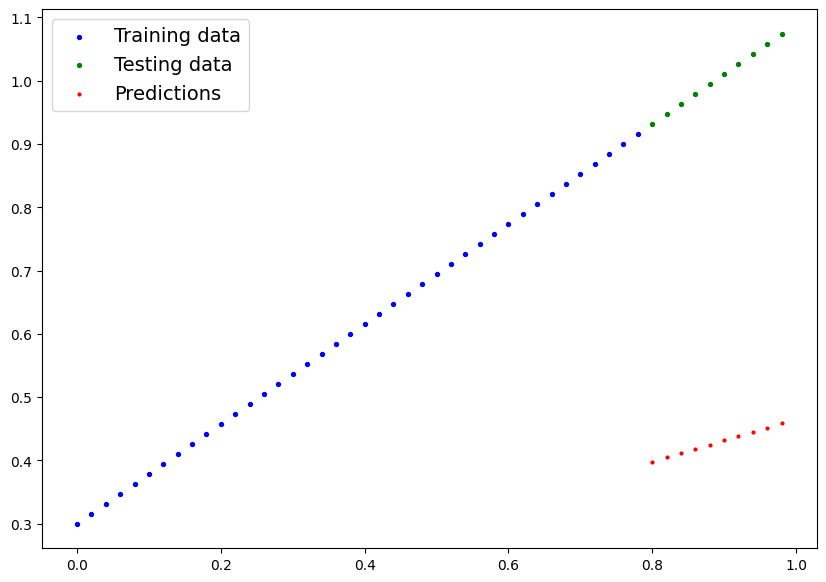

In [ ]:
plot_predictions(predictions=y_preds)

## 3 Train model
The whole idea of training is for a model to move from some **unknown** parameters(these may be random) to some *known* parameters

Or in other words from a poor representation of the data to a better representation of the data

One way to measure how poor or how wrong your model predictions are is to use a loss function

*Note: Loss function may also be called  cost function or criterio in diffrent areas. For our case, we are going to refer to it as  loss function

Things we need to train:

**loss function**: A function to measures how wrong your model's predictions are to the ideal outputs, the lower the better
**Optimizer** takes into account the loss of a model and adjusts the model parameters(eg weight and bias in our case) to improve the loss function.

and specifically for pytorch we need
- Training loop
- testing loop

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Creating a loss function and optimizer in PyTorch

For our model to update its parameters on its own, we'll need to add a few more things to our recipe.

And that's a **loss function** as well as an **optimizer**.

The rolls of these are:

| Function | What does it do? | Where does it live in PyTorch? | Common values |
| ----- | ----- | ----- | ----- |
| **Loss function** | Measures how wrong your model's predictions (e.g. `y_preds`) are compared to the truth labels (e.g. `y_test`). Lower the better. | PyTorch has plenty of built-in loss functions in [`torch.nn`](https://pytorch.org/docs/stable/nn.html#loss-functions). | Mean absolute error (MAE) for regression problems ([`torch.nn.L1Loss()`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)). Binary cross entropy for binary classification problems ([`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)).  |
| **Optimizer** | Tells your model how to update its internal parameters to best lower the loss. | You can find various optimization function implementations in [`torch.optim`](https://pytorch.org/docs/stable/optim.html). | Stochastic gradient descent ([`torch.optim.SGD()`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD)). Adam optimizer ([`torch.optim.Adam()`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)). |

Let's create a loss function and an optimizer we can use to help improve our model.

Depending on what kind of problem you're working on will depend on what loss function and what optimizer you use.

However, there are some common values, that are known to work well such as the SGD (stochastic gradient descent) or Adam optimizer. And the MAE (mean absolute error) loss function for regression problems (predicting a number) or binary cross entropy loss function for classification problems (predicting one thing or another).

For our problem, since we're predicting a number, let's use MAE (which is under `torch.nn.L1Loss()`) in PyTorch as our loss function.

![what MAE loss looks like for our plot data](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-mae-loss-annotated.png)
*Mean absolute error (MAE, in PyTorch: `torch.nn.L1Loss`) measures the absolute difference between two points (predictions and labels) and then takes the mean across all examples.*

And we'll use SGD, `torch.optim.SGD(params, lr)` where:

* `params` is the target model parameters you'd like to optimize (e.g. the `weights` and `bias` values we randomly set before).
* `lr` is the **learning rate** you'd like the optimizer to update the parameters at, higher means the optimizer will try larger updates (these can sometimes be too large and the optimizer will fail to work), lower means the optimizer will try smaller updates (these can sometimes be too small and the optimizer will take too long to find the ideal values). The learning rate is considered a **hyperparameter** (because it's set by a machine learning engineer). Common starting values for the learning rate are `0.01`, `0.001`, `0.0001`, however, these can also be adjusted over time (this is called [learning rate scheduling](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate)).

Woah, that's a lot, let's see it in code.

In [ ]:
MAE_loss = torch.mean(torch.abs(y_preds-y_test))
MAE_loss

tensor(0.5746)

In [ ]:
#check out our model's parameters(a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
#Setup a loss function
loss_fn  = nn.L1Loss()
loss_fn

L1Loss()

In [ ]:
#Setup an optimizer(Stochastic gradient descent)
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01 #lr learning rate = possibly the most important hyperparameter you can set
                                      #how much the optimizer should change parameters at each step, higher=more(less stable), lower=less(might take a long time),
                            )

**Q:** Which loss function and optimizer should i use?
**A:** This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression problem(like ours), a loss function `nn.Lloss()` and an optimizer like `torch.optim.SGD` will suffice

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of `nn.BCELoss() (binary cross entropy loss)`

### Build a training loop in PyTorch
A couple of things we need in a training loop:

0. Loop through the data and do...
1. Forward pass (this involves data moving through our model's `forward`() functions) to make predictions on data - also called forward propagation
2. Calculate the loss(Compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss(**backpropagation**)
5. Optimizer step- use the optimizer to adjust our models parameters to try and improve our loss(**gradient descent  **)




### PyTorch training loop
For the training loop, we'll build the following steps:

| Number | Step name | What does it do? | Code example |
| ----- | ----- | ----- | ----- |
| 1 | Forward pass | The model goes through all of the training data once, performing its `forward()` function calculations. | `model(x_train)` |
| 2 | Calculate the loss | The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are. | `loss = loss_fn(y_pred, y_train)` |
| 3 | Zero gradients | The optimizers gradients are set to zero (they are accumulated by default) so they can be recalculated for the specific training step. | `optimizer.zero_grad()` |
| 4 | Perform backpropagation on the loss | Computes the gradient of the loss with respect for every model parameter to be updated  (each parameter with `requires_grad=True`). This is known as **backpropagation**, hence "backwards".  | `loss.backward()` |
| 5 | Update the optimizer (**gradient descent**) | Update the parameters with `requires_grad=True` with respect to the loss gradients in order to improve them. | `optimizer.step()` |

![pytorch training loop annotated](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-training-loop-annotated.png)

> **Note:** The above is just one example of how the steps could be ordered or described. With experience you'll find making PyTorch training loops can be quite flexible.
>
> And on the ordering of things, the above is a good default order but you may see slightly different orders. Some rules of thumb:
> * Calculate the loss (`loss = ...`) *before* performing backpropagation on it (`loss.backward()`).
> * Zero gradients (`optimizer.zero_grad()`) *before* computing the gradients of the loss with respect to every model parameter (`loss.backward()`).
> * Step the optimizer (`optimizer.step()`) *after* performing backpropagation on the loss (`loss.backward()`).

For resources to help understand what's happening behind the scenes with backpropagation and gradient descent, see the extra-curriculum section.




### PyTorch testing loop

As for the testing loop (evaluating our model), the typical steps include:

| Number | Step name | What does it do? | Code example |
| ----- | ----- | ----- | ----- |
| 1 | Forward pass | The model goes through all of the testing data once, performing its `forward()` function calculations. | `model(x_test)` |
| 2 | Calculate the loss | The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are. | `loss = loss_fn(y_pred, y_test)` |
| 3 | Calulate evaluation metrics (optional) | Alongside the loss value you may want to calculate other evaluation metrics such as accuracy on the test set. | Custom functions |

Notice the testing loop doesn't contain performing backpropagation (`loss.backward()`) or stepping the optimizer (`optimizer.step()`), this is because no parameters in the model are being changed during testing, they've already been calculated. For testing, we're only interested in the output of the forward pass through the model.

![pytorch annotated testing loop](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-testing-loop-annotated.png)

Let's put all of the above together and train our model for 100 **epochs** (forward passes through the data) and we'll evaluate it every 10 epochs.


In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
torch.manual_seed(42)
#An epoch is one loop through the data(this is a hyperparameter becasue we have set it oursleves)
#An epoch is one loop through the data ...(how many times the model will pass through the training data)
epochs = 300

#Track different values
epoch_count = []
train_loss_values = []
test_loss_values = []

#Training
#0. loop through the data
for  epoch in range(epochs):
  #set the model to training mode
  model_0.train() #train mode in Pytorch sets all parameters that require gradients to require gradient



#1. Forwad pass
  y_pred = model_0(X_train)
  # print(y_pred)

#2.Claculate the loss
  loss = loss_fn(y_pred,y_train)
  # print(f'loss:{loss}')

#3.Optimizer zero grad
  optimizer.zero_grad()

#4. Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

#Step the optimizer(perform gradient desccent)
  optimizer.step() #by default how the optimizer changes will acculate through the loop so ... we have to zero them above in step 3 for the next iteration of the loop

  #Testing
  model_0.eval() #turns off different setting in the model not needed for evaluation/ testing(dropout/batch norm)
  with torch.inference_mode(): #turns off gradient tracking & a couple more things behind the scenes
  # with torch.no_grad(): #in older pytorch code but inference mode is the better way
  # 1. Do the Forward pass
    test_pred = model_0(X_test)
  # 2.Calculate the loss
    test_loss = loss_fn(test_pred, y_test)
    epoch_count.append(epoch)
    train_loss_values.append(loss.detach().numpy())
    test_loss_values.append(test_loss)
    if epoch % 10 == 0:
      print(f'Epoch :{epoch} | loss: {loss} | Test Loss: {test_loss}')

#Print out model state_dict()
print(model_0.state_dict())

Epoch :0 | loss: 0.34798139333724976 | Test Loss: 0.5611652135848999
Epoch :10 | loss: 0.2327713519334793 | Test Loss: 0.42645519971847534
Epoch :20 | loss: 0.12308676540851593 | Test Loss: 0.29633432626724243
Epoch :30 | loss: 0.07651860266923904 | Test Loss: 0.21186228096485138
Epoch :40 | loss: 0.06321538984775543 | Test Loss: 0.1672699898481369
Epoch :50 | loss: 0.057989973574876785 | Test Loss: 0.14346599578857422
Epoch :60 | loss: 0.054297469556331635 | Test Loss: 0.1304120123386383
Epoch :70 | loss: 0.050807468593120575 | Test Loss: 0.11939194053411484
Epoch :80 | loss: 0.04734305664896965 | Test Loss: 0.10974564403295517
Epoch :90 | loss: 0.04390813037753105 | Test Loss: 0.10215996205806732
Epoch :100 | loss: 0.04047824814915657 | Test Loss: 0.09388742595911026
Epoch :110 | loss: 0.037039436399936676 | Test Loss: 0.0856148898601532
Epoch :120 | loss: 0.03360620141029358 | Test Loss: 0.07802923023700714
Epoch :130 | loss: 0.030174633488059044 | Test Loss: 0.06975668668746948
Epo

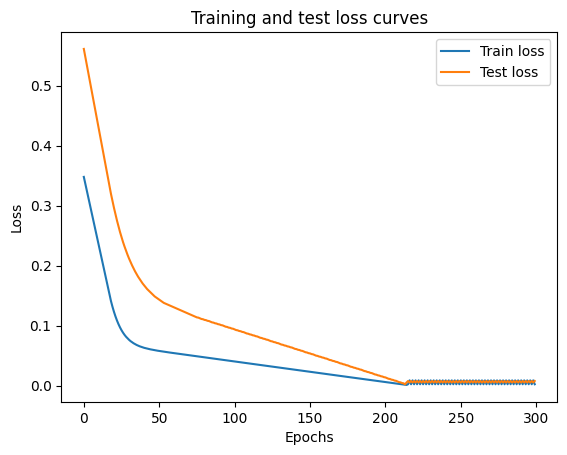

In [ ]:
#plot the loss curves
import numpy as np
plt.plot(epoch_count,train_loss_values,label='Train loss')
plt.plot(epoch_count,test_loss_values,label='Test loss')
plt.title('Training and test loss curves')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend();

Nice! The **loss curves** show the loss going down over time. Remember, the loss is the meausre of how wrong your model is, so the lower the better

But why did the loss go down?
Well, thanks to our loss function and optimizer, the model's internal parameters(`weight` and `bias`) were updated to better reflect the underlying patterns in thr data

Let's inspect our model's  [`.state_dict()`](https://pytorch.org/tutorials/recipes/recipes/what_is_state_dict.html) to see how close our model gets to the original values we set for weights and bias

In [ ]:
#Find our model's learned parameters
print('The model learned the following values for weight and bias:')
print(model_0.state_dict())
print('\nAnd the original values for weight and bias are:')
print(f'weights: {weight}, bias:{bias}')

The model learned the following values for weight and bias:
OrderedDict({'weights': tensor([0.7879]), 'bias': tensor([0.3098])})

And the original values for weight and bias are:
weights: 0.79, bias:0.3


Wow!How cool is that?

Our model got very close to calculating the exact original values for `weight` and `bias` (and it would probably get even closer if we trained for longer)

> **Exercise:** Try changing the `epochs` value above to 200, what happens to the loss curves and the weights and bias parameter values of the model?

It'd likely never guess them *perfectly* (especially when using more complicated datasets) but that's okay, often you can do very cool things with a close approximation.

This is the whole idea of machine learning and deep learning, **there are some ideal values that describe our data** and rather than figuring them out by hand, **we can train a model to figure them out programmatically**.

## 4. Making predictions with a trained PyTorch model (inference)

Once you've trained a model, you'll likely want to make predictions with it.

We've already seen a glimpse of this in the training and testing code above, the steps to do it outside of the training/testing loop are similar.

There are three things to remember when making predictions (also called performing inference) with a PyTorch model:

1. Set the model in evaluation mode (`model.eval()`).
2. Make the predictions using the inference mode context manager (`with torch.inference_mode(): ...`).
3. All predictions should be made with objects on the same device (e.g. data and model on GPU only or data and model on CPU only).

The first two items make sure all helpful calculations and settings PyTorch uses behind the scenes during training but aren't necessary for inference are turned off (this results in faster computation). And the third ensures that you won't run into cross-device errors.

In [ ]:
with torch.inference_mode():
  y_preds_new =model_0(X_test)


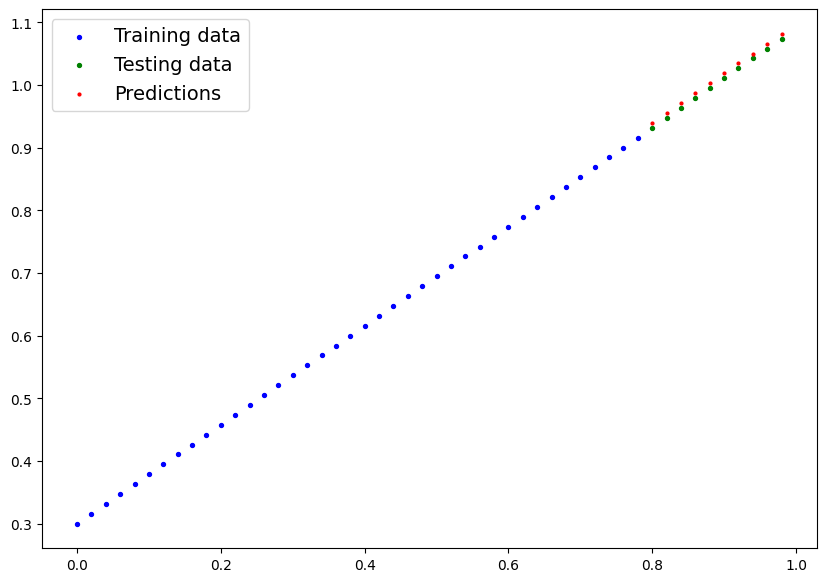

In [ ]:
plot_predictions(predictions=y_preds_new)

## 5. Saving and loading a PyTorch model

There are three main methods you should for saving and loading models in PyTorch

1. `torch.save()` - allows you to save a PyTorch object in Pythons pickle format
serializing-save, deserealization(loading)
2. `torch.load()` - allows you a saved PyTorch object
3. `torch.nn.Module.load_state_dict`() - this allows to load a model's saved state  dictionary



In [ ]:
#saving our pytorch model
from pathlib import Path

#1. Create models directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. Create model save path
MODEL_NAME = '01_pytorch_workflow_model_0.pth'
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME #PosixPath('models/01_pytorch_workflow_model_0.pth')

#2. Save the model state dict
print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
!ls -l models

total 8
-rw-r--r-- 1 root root 2117 Jan 16 14:52 01_pytorch_workflow_model_0.pth
-rw-r--r-- 1 root root 2245 Jan 16 14:40 01_Pytorch_workflow_model_1.pth


## Loading a Pytorch model

Since we saved our model's `state_dict()` rather than the entire model, we'll create a new instance of our model class and load the saved`state-dict` into that

### Loading a saved PyTorch model's `state_dict()`

Since we've now got a saved model `state_dict()` at `models/01_pytorch_workflow_model_0.pth` we can now load it in using `torch.nn.Module.load_state_dict(torch.load(f))` where `f` is the filepath of our saved model `state_dict()`.

Why call `torch.load()` inside `torch.nn.Module.load_state_dict()`?

Because we only saved the model's `state_dict()` which is a dictionary of learned parameters and not the *entire* model, we first have to load the `state_dict()` with `torch.load()` and then pass that `state_dict()` to a new instance of our model (which is a subclass of `nn.Module`).

Why not save the entire model?

[Saving the entire model](https://pytorch.org/tutorials/beginner/saving_loading_models.html#save-load-entire-model) rather than just the `state_dict()` is more intuitive, however, to quote the PyTorch documentation (italics mine):

> The disadvantage of this approach *(saving the whole model)* is that the serialized data is bound to the specific classes and the exact directory structure used when the model is saved...
>
> Because of this, your code can break in various ways when used in other projects or after refactors.

So instead, we're using the flexible method of saving and loading just the `state_dict()`, which again is basically a dictionary of model parameters.

Let's test it out by creating another instance of `LinearRegressionModel()`, which is a subclass of `torch.nn.Module` and will hence have the in-built method `load_state_dict()`.

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.7879])), ('bias', tensor([0.3098]))])

In [ ]:
# To load in saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

#Load the saved state_dict model of model_o (this will update the new instance with updated params)
loaded_model_0.state_dict() #initalized with random parameters
#modelB.load_state_dict(torch.load(PATH, weights_only=True), strict=False)
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH,weights_only=False,map_location='cpu'))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.7879])), ('bias', tensor([0.3098]))])

In [ ]:
#Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.9402],
        [0.9559],
        [0.9717],
        [0.9874],
        [1.0032],
        [1.0190],
        [1.0347],
        [1.0505],
        [1.0662],
        [1.0820]])

In [ ]:
#compare loaded model preds with original model preds
y_preds_new == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6.Putting it all together
we go back all the steps above and see it all in one place

In [ ]:
# Import Pytorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

#check pytorch version
torch.__version__

'2.9.0+cu126'

Create device agnostic code

This means if we've got access to a GPU, our code will use it(for potentially faster computing)

if no GPU availble, the code will default to using CPU

In [ ]:
#Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using devide: {device}')

Using devide: cuda


### 6.1 Data

In [ ]:
# Create some data using the linear regresion formula of y= weight * X + bias
weight = 0.7
bias = 0.3

#Create range values
start=0
end = 1
step = 0.02

#create X and y (features and labels respectively)

X = torch.arange(start,end,step).unsqueeze(dim=1) #without unsqueeze error will popup
y = weight * X +bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
#split data
train_split = int(0.8 * len(X))
X_train, y_train  = X[:train_split],y[:train_split]
X_test, y_test = X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

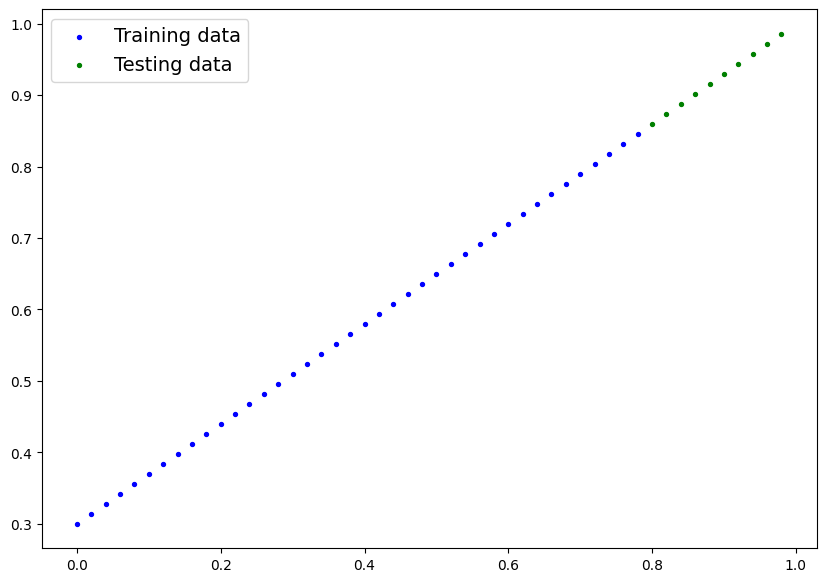

In [ ]:
#plot the data
#NB if no plot_predictions function, will throw an error
plot_predictions(X_train,y_train,X_test,y_test)

 ### 6.2 Build a PyTorch Linear Model


We've got some data, now it's time to make a model.

We'll create the same style of model as before except this time, instead of defining the weight and bias parameters of our model manually using `nn.Parameter()`, we'll use [`nn.Linear(in_features, out_features)`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) to do it for us.

Where `in_features` is the number of dimensions your input data has and `out_features` is the number of dimensions you'd like it to be output to.

In our case, both of these are `1` since our data has `1` input feature (`X`) per label (`y`).

![comparison of nn.Parameter Linear Regression model and nn.Linear Linear Regression model](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-linear-regression-model-with-nn-Parameter-and-nn-Linear-compared.png)
*Creating a linear regression model using `nn.Parameter` versus using `nn.Linear`. There are plenty more examples of where the `torch.nn` module has pre-built computations, including many popular and useful neural network layers.*

In [ ]:
# Create a linear model by subclassing nn.module
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    #Use nn.linear() for creating the model parameters/ also called linear_transform, probing layer,fully connected layer, dense layer
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)
  # Define the forward computation (input data x flows through nn.Linear())
  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)


# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()

model_1, model_1.state_dict()


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

Notice the outputs of `modelmodel_1.state_dict()`, the `nn.linear()` layer created a random `weight` and `bias` parameter for us

Now let's put our model on the GPU(if it's available)

We can change the device out PyTorch are on using `.to(device)`

In [ ]:
#check current model device
next(model_1.parameters()).device

device(type='cpu')

Wonderful, looks like the model's on the CPU by default

Let's change it to be on the GPU(if its available)

In [ ]:
#Set model to GPU if it's available, otherwise default to cpu
model_1.to(device) #The device variable was set above to be 'cuda' if available or 'cpu' if not
next(model_1.parameters()).device

device(type='cuda', index=0)

Nice! Because of our device agnostic code, the above cell will work regardless of whether a GPU is available or not.

If you do have access to a CUDA-enabled GPU, you should see an output of something like:
```
device(type='cuda', index=0)
```

### 6.3 Training

For Training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop


In [ ]:
# setup loss function
loss_fn  = nn.L1Loss() #Same as MAE

#Setup our optimizer-We'll have to pass the new model's parameters (model.parameters()) to the optimizer for it to adjust them during training.
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr=0.01) #too big step our  model learns too fast and explodes, too small of a step our model nevers learns anything
#

In [ ]:
#lets write the training loop
torch.manual_seed(42)
epochs = 1000

#put data on the target device (device agnostic for data)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  #1.forward pass
  y_pred = model_1(X_train)

  #2.Calculate the loss (how different are our models predictions to the ground truth)
  loss = loss_fn(y_pred, y_train)

  #3. Zero grad of the optimizer
  optimizer.zero_grad()

  #perform backpropagation
  loss.backward()

  #Optimizer step
  optimizer.step()

  #Testing
  model_1.eval()

  with torch.inference_mode():
    #1.Forward pass on test data
    test_pred = model_1(X_test)

    #2.test loss
    test_loss = loss_fn(test_pred,y_test)

    #prints whats happening
    if epoch % 10 ==0:
      print(f'Epoch: {epoch} | Loss: {loss} | Test Loss:{test_loss}')

Epoch: 0 | Loss: 0.5551779866218567 | Test Loss:0.5739762187004089
Epoch: 10 | Loss: 0.439968079328537 | Test Loss:0.4392664134502411
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss:0.30455657839775085
Epoch: 30 | Loss: 0.20954833924770355 | Test Loss:0.16984669864177704
Epoch: 40 | Loss: 0.09433845430612564 | Test Loss:0.03513690456748009
Epoch: 50 | Loss: 0.023886388167738914 | Test Loss:0.04784907028079033
Epoch: 60 | Loss: 0.019956795498728752 | Test Loss:0.045803118497133255
Epoch: 70 | Loss: 0.016517987474799156 | Test Loss:0.037530567497015
Epoch: 80 | Loss: 0.013089174404740334 | Test Loss:0.02994490973651409
Epoch: 90 | Loss: 0.009653178043663502 | Test Loss:0.02167237363755703
Epoch: 100 | Loss: 0.006215683650225401 | Test Loss:0.014086711220443249
Epoch: 110 | Loss: 0.00278724217787385 | Test Loss:0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test Loss:0.013801801018416882
Epoch: 130 | Loss: 0.0012645035749301314 | Test Loss:0.013801801018416882
Epoch: 140

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

Ho ho! Now that's pretty darn close to a perfect model.

Remember though, in practice, it's rare that you'll know the perfect parameters ahead of time.

And if you knew the parameters your model had to learn ahead of time, what would be the fun of machine learning?

Plus, in many real-world machine learning problems, the number of parameters can well exceed tens of millions.

I don't know about you but I'd rather write code for a computer to figure those out rather than doing it by hand.

### 6.4  Making and evaluating predcitions

In [ ]:
#Turn model into evaluation model
model_1.eval()

#Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds


tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

If you're making predictions with data on the GPU, you might notice the output of the above has `device='cuda:0'` towards the end. That means the data is on CUDA device 0 (the first GPU your system has access to due to zero-indexing), if you end up using multiple GPUs in the future, this number may be higher.

Now let's plot our model's predictions.

> **Note:** Many data science libraries such as pandas, matplotlib and NumPy aren't capable of using data that is stored on GPU. So you might run into some issues when trying to use a function from one of these libraries with tensor data not stored on the CPU. To fix this, you can call [`.cpu()`](https://pytorch.org/docs/stable/generated/torch.Tensor.cpu.html) on your target tensor to return a copy of your target tensor on the CPU.

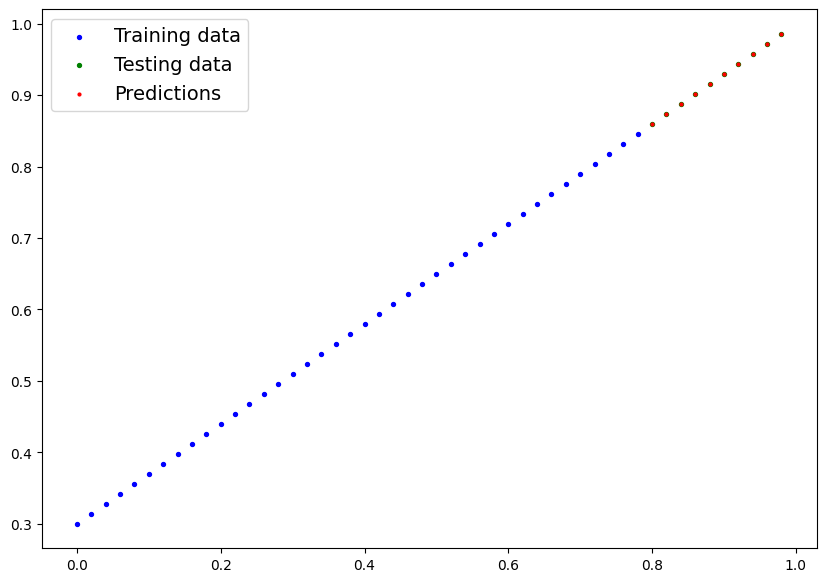

In [ ]:
#Check our model predictions visualy
# plot_predictions(predictions=y_preds.cpu())
plot_predictions(
    train_data=X_train.cpu(),
    train_labels=y_train.cpu(),
    test_data=X_test.cpu(),
    test_labels=y_test.cpu(),
    predictions=y_preds.cpu()
)


Woah! Look at those red dots, they line up almost perfectly with the green dots. I guess the extra epochs helped.


### 6.5 Saving and loading a model
We're happy with our models predictions, so let's save it to file so it can be used later.

In [ ]:
#saving our pytorch model
from pathlib import Path

#1.Create models directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2.Create model save path
MODEL_NAME = '01_Pytorch_workflow_model_1.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3.Save the model state dict
print(f'saving model to: {MODEL_SAVE_PATH}')
torch.save(obj=model_1.state_dict(),#onlt saving the state_dict() only
           f=MODEL_SAVE_PATH)

saving model to: models/01_Pytorch_workflow_model_1.pth


And just to make sure everything worked well, let's load it back in.

We'll:
* Create a new instance of the `LinearRegressionModelV2()` class
* Load in the model state dict using `torch.nn.Module.load_state_dict()`
* Send the new instance of the model to the target device (to ensure our code is device-agnostic)

In [ ]:
#Instatntiate a fresh instance of LinearRegressionModelV2
loaded_model_1 = LinearRegressionModelV2()

#load model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

#Put model to target device(if your data is on GPU, model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f'Loaded model: \n {loaded_model_1}')
print(f'Model on device: \n {next(loaded_model_1.parameters())}')

Loaded model: 
 LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device: 
 Parameter containing:
tensor([[0.6968]], device='cuda:0', requires_grad=True)


Now we can evaluate the loaded model to see if its predictions line up with the predictions made prior to saving

In [ ]:
#Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)

y_preds == loaded_model_1_preds


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

Everything adds up! Nice!

well, we've come along way. You've now built na trained your first two neural networks models in pytorch!